#### Load the Data

In [23]:
import pandas as pd

# Load the preprocessed datasets
"""
X_train = pd.read_csv("preprocessed_data/X_train.csv")
X_test = pd.read_csv("preprocessed_data/X_test.csv")
y_train = pd.read_csv("preprocessed_data/y_train.csv")
y_test = pd.read_csv("preprocessed_data/y_test.csv")
"""
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the single processed file
data = pd.read_csv("preprocessed_data/processed_mushrooms.csv")

# 2. Separate X and y
X = data.drop('class', axis=1)
y = data['class']

# 3. Perform the split right before training
# Changing random_state will give you a different 'random' split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Recommended to keep the class distribution consistent
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 6499
Testing set size: 1625


#### Implement the MLP Classifier

In [24]:
from sklearn.neural_network import MLPClassifier

# Initialize the MLP
# hidden_layer_sizes=(100, 50) means two hidden layers with 100 and 50 neurons
# activation='relu' is the standard for deep learning
# max_iter determines how many epochs to train
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500,
    activation='relu',
    solver='adam',
    random_state=42,
    verbose=False # Set to True to see the loss decrease during training
)

# Train the model
mlp.fit(X_train, y_train)

print("MLP Model training complete.")

MLP Model training complete.


#### Evaluate Performance

MLP Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       842
           1       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



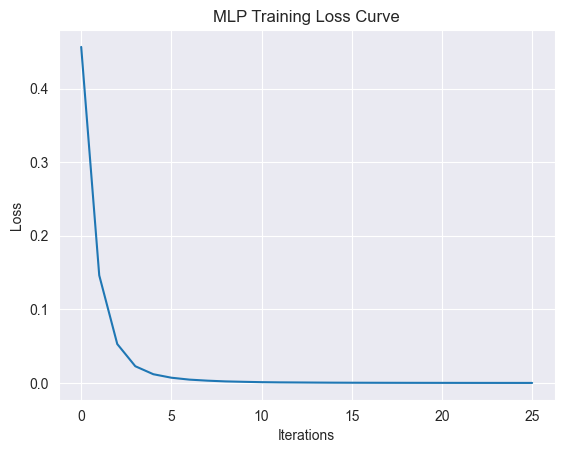

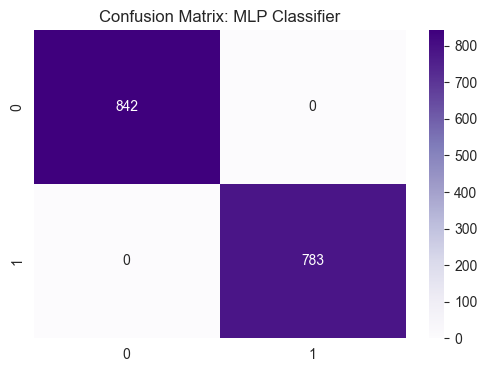

In [25]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred = mlp.predict(X_test)

# Evaluation metrics
print(f"MLP Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Plot the Loss Curve
plt.plot(mlp.loss_curve_)
plt.title("MLP Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Purples')
plt.title('Confusion Matrix: MLP Classifier')
plt.show()

K-Fold Cross-Validation

In [30]:
from sklearn.model_selection import cross_validate

# Define the metrics you want to track
scoring = ['accuracy', 'precision', 'recall', 'f1']

# Perform 5-fold cross-validation
results = cross_validate(mlp, X_train, y_train, cv=5, scoring=scoring, return_train_score=True)

# Convert to a DataFrame for a beautiful display in Jupyter
import pandas as pd
results_df = pd.DataFrame(results)
display(results_df)

# Print the mean of the test metrics
print(f"Mean Test Accuracy: {results_df['test_accuracy'].mean():.4f}")
print(f"Mean Test F1-Score: {results_df['test_f1'].mean():.4f}")

,fit_time,score_time,test_accuracy,train_accuracy,test_precision,train_precision,test_recall,train_recall,test_f1,train_f1
0,0.484996,0.005997,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1,0.465000,0.003999,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
2,0.465003,0.004000,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
3,0.460003,0.004999,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
4,0.494001,0.003999,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


Mean Test Accuracy: 1.0000
Mean Test F1-Score: 1.0000


Permutation Importance check(Robustness)

In [31]:
from sklearn.inspection import permutation_importance
import pandas as pd

# This will take a moment as it re-evaluates the model multiple times
result = permutation_importance(mlp, X_test, y_test, n_repeats=10, random_state=42)

# Organize the results
feature_names = X_train.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': result.importances_mean,
    'importance_std': result.importances_std
}).sort_values(ascending=False, by='importance_mean')

# Print the top 10 features
print(importance_df.head(10))

                     feature  importance_mean  importance_std
20               gill-size_n         0.028800        0.001477
34              stalk-root_c         0.006462        0.001207
32             stalk-shape_t         0.005538        0.001291
72       spore-print-color_r         0.004492        0.000282
36              stalk-root_r         0.003015        0.000431
64               ring-type_f         0.002646        0.000394
68       spore-print-color_h         0.001969        0.000769
17                 bruises_t         0.001477        0.000628
54  stalk-color-below-ring_n         0.001415        0.000481
6              cap-surface_s         0.001046        0.000955
